# 25. The `Rescattering2` pi-pi/KK S-wave

**Objectives:**
- Build `Rescattering2`, the port of Laura++'s `LauRescattering2Res` two-region Chebyshev
  rescattering S-wave, with default coefficients.
- Show the amplitude is exactly zero below the charged-kaon threshold `2*m_K` and nonzero
  above it, and note the class's documented deliberate deviation from the literal Laura++
  source.
- Embed it in a minimal one-resonance `DecayModel`, generate a toy, and recover a floated
  Cartesian coefficient with `FitSession.fit()`.

Run the cells in order in a fresh kernel. Masses are in GeV, invariants in GeV^2, and
daughter indices start at zero.

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede numerical work: amplitudes use complex128.

import jax.numpy as jnp
import matplotlib.pyplot as plt

from dalitzplotfitter import (
    DecayChannel, DecayModel, FitSession, NonResonant,
    Parameter, RealImag, Rescattering2, Resonance, generate_toy,
)
from dalitzplotfitter.dynamics.context import ResonanceContext

## 1. Threshold behavior

`Rescattering2`'s docstring gives the amplitude as
`A(m) = g_00(m) exp(i phi_00(m)) / (1 + m^2/Lambda^2)`, with separate Chebyshev expansions
below and above a 1.47 GeV transition mass, and `g_00(m) = 0` below the charged-kaon
threshold `2*m_K` -- `LauRescattering2Res::resAmp` sets `mag = 0` there. `threshold_mass` is
exposed as a property (`2 * kaon_mass`).

threshold_mass (2*m_K) = 0.987354 GeV
transition_mass        = 1.47 GeV
maximum_mass            = 2.0 GeV


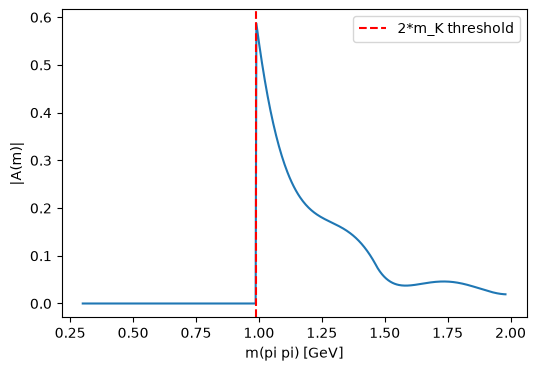

In [2]:
rescattering = Rescattering2()  # Laura++ default coefficients
print(f"threshold_mass (2*m_K) = {rescattering.threshold_mass:.6f} GeV")
print(f"transition_mass        = {rescattering.transition_mass} GeV")
print(f"maximum_mass            = {rescattering.maximum_mass} GeV")

mpi = 0.13957039
context = ResonanceContext(
    parent_mass=1.86965, daughter_masses=(mpi, mpi), bachelor_mass=mpi,
    spin=0, pole_mass=1.5, pole_width=0.0,
)
mass_scan = jnp.linspace(0.30, 1.98, 600)
amplitude_scan = rescattering(mass_scan, context)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mass_scan, jnp.abs(amplitude_scan))
ax.axvline(rescattering.threshold_mass, color="red", linestyle="--",
           label="2*m_K threshold")
ax.set(xlabel="m(pi pi) [GeV]", ylabel="|A(m)|")
ax.legend()
plt.show()

## 2. Zero exactly below threshold, nonzero above

Check both sides of `threshold_mass` explicitly.

In [3]:
below = jnp.linspace(0.28, rescattering.threshold_mass - 1e-4, 50)
above = jnp.linspace(rescattering.threshold_mass + 1e-4, 1.98, 50)

values_below = rescattering(below, context)
values_above = rescattering(above, context)

assert bool(jnp.all(jnp.abs(values_below) == 0.0))
assert bool(jnp.all(jnp.abs(values_above) > 0.0))
print("Amplitude is exactly zero for every mass below 2*m_K, and nonzero above it.")

Amplitude is exactly zero for every mass below 2*m_K, and nonzero above it.


The class docstring flags one deliberate deviation from the literal Laura++ source: the
high-mass Chebyshev region's constant terms (`C0`, `F0`) are anchored at `transition_mass`
itself rather than at `transition_mass**2` (a dimensionally inconsistent value the upstream
C++ appears to pass by mistake). This choice also makes the two Chebyshev regions continuous
at the transition, which the literal squared-mass anchor would not -- `resAmp`'s zero-below-
threshold cut is unaffected by this and is reproduced exactly as in Laura++.

## 3. A minimal one-resonance Dalitz model

`Rescattering2.__call__` requires `spin=0`, like `LASS`/`KMatrix`. We use
`D+ -> pi- pi+ pi+` with the rescattering S-wave on the `(0, 1)` pi-pi pair, plus a small
non-resonant term for interference.

In [4]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))

def coeff(name, x0, y0):
    return RealImag(
        Parameter.coefficient(f"{name}.x", x0, owner=name, bounds=(-3.0, 3.0)),
        Parameter.coefficient(f"{name}.y", y0, owner=name, bounds=(-3.0, 3.0)),
    )

model = DecayModel(
    channel,
    components=[
        Resonance(
            "pipi_rescatter", pair=(0, 1), coefficient=coeff("pipi_rescatter", 1.0, 0.0),
            lineshape=Rescattering2(), mass=1.5, width=0.05, spin=0,
            normalize_component=False,
        ),
        NonResonant(coeff("NR", 0.20, -0.05), name="NR"),
    ],
    normalization_method="square-dalitz", normalization_pair=(0, 1),
    normalization_resolution=40,
)
truth = {p.name: p.value for p in model.parameters}
print("Floating parameters:", list(truth))

Floating parameters: ['pipi_rescatter.x', 'pipi_rescatter.y', 'NR.x', 'NR.y']


## 4. Generate a toy and fit the Cartesian coefficient

We generate a small toy at the truth values and float `pipi_rescatter.x`/
`pipi_rescatter.y` from a displaced starting point, keeping everything else fixed.

In [5]:
toy = generate_toy(
    model, 1500, parameters=truth, seed=25,
    method="inverse-transform", inverse_resolution=256,
    include_momenta=False,
)
print(f"Generated {toy.size} toy events")

session = FitSession(model, toy)
start = {"pipi_rescatter.x": 0.7, "pipi_rescatter.y": 0.3}
result = session.fit(start, simplex=True, ncall=4000)
session.report(result)
assert result.valid, "Inspect the fit diagnostics before using this result."

fit_values = {n: float(result.values[n]) for n in result.parameters}
fit_nll = float(session.objective(fit_values))
truth_nll = float(session.objective(truth))
print(f"NLL(fit)={fit_nll:.4f}, NLL(truth)={truth_nll:.4f}")
assert fit_nll <= truth_nll + 1e-3
print("The fit converged to a valid minimum with NLL at or below the truth NLL.")

Generated 1500 toy events


valid=True  NLL=968.138873
parameter                           value            error
pipi_rescatter.x                  2.67204          4.40262
pipi_rescatter.y                -0.140085          2.46834
NR.x                             0.577065         0.336133
NR.y                           -0.0319917         0.621893


Fit fractions (physical)
component                    fraction [%]
pipi_rescatter                    143.521
NR                                 17.737
sum                               161.258


NLL(fit)=968.1389, NLL(truth)=973.2451
The fit converged to a valid minimum with NLL at or below the truth NLL.


## Summary

- `Rescattering2` is a two-region Chebyshev pi-pi/KK S-wave, zero below the charged-kaon
  threshold `2*m_K` (its `threshold_mass` property) by construction, matching
  `LauRescattering2Res::resAmp`.
- Its docstring documents one deliberate departure from the literal Laura++ source (the
  high-mass region's constant-term anchor), justified there as both dimensionally consistent
  and continuous at the transition mass.
- Like `LASS`/`KMatrix`, it requires `spin=0`, and its Cartesian coefficient floats through
  `FitSession.fit()` exactly like any other resonance.

See `docs/lineshapes.md` for the full lineshape catalog.

Return to [the course guide](TUTORIALS.md).